**Họ tên:** Chu Thị Bảo Ngọc\
**MSHV:** 22C01035

<hr style="border:1px solid black">

# <h1><center>**BÀI TẬP CUỐI KỲ**</center></h1>
## <h1><center>**Môn: Thị giác máy tính chuyên sâu**</center></h1>
\
<hr style="border:1px solid black">

# First-level requirement:
### Train and generate images for one class of the dataset using vanilla GAN.

In [1]:
!pip install tensorflow_datasets

# Import libraries
from google.colab import files
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from keras import Model
from keras import utils
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras.optimizers.legacy import Adam, SGD
from keras.models import Sequential
from keras.layers import Activation, Conv2D, Dense, MaxPooling2D, Flatten, Conv2DTranspose, LeakyReLU, Reshape, Dropout, BatchNormalization, GlobalMaxPooling2D, Flatten, Dense

In [2]:
# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

# Seperate feature X and label Y
X_train, y_train = cifar10_train["image"], cifar10_train["label"]
X_test, y_test = cifar10_test["image"], cifar10_test["label"]

# Print shapes of the entire training and test set of CIFAR 10
print("X_train shape: " + str(X_train.shape))
print("X_test shape: " + str(X_test.shape))
print("y_train shape: " + str(y_train.shape))
print("y_test shape: " + str(y_test.shape))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incomplete1OJB8E/cifar10-train.tfrecord*...:   0%|          …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incomplete1OJB8E/cifar10-test.tfrecord*...:   0%|          |…

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000,)
y_test shape: (10000,)


In [3]:
# Get samples  of a certain label. You can choose from one of the classes:
# 0 - airplane; 1 - automobile; 2 - bird; 3 - cat; 4 - deer; 5 - dog; 6 - frog; 7 - horse; 8 - ship; 9 - truck

label = 2                                   # Class '2' is bird
train_indices = np.where(y_train == label)  # Get indices of the label
train_set = X_train[train_indices]          # Get train samples of the label
test_indices = np.where(y_test == label)    # Get indices of the label
test_set = X_test[test_indices]             # Get test samples of the label

# Print shapes of datasets of the selected class
print("Train_set shape of the selected class: " + str(train_set.shape))
print("Test_set shape of the selected class: " + str(test_set.shape))

# NOTE: Training a GAN doesn't require to have train/test split. You should merge the train_set and test_set into one dataset, which can be used as real data samples
data = np.vstack((train_set, test_set))
print("Dataset shape of the selected class: " + str(data.shape))

Train_set shape of the selected class: (5000, 32, 32, 3)
Test_set shape of the selected class: (1000, 32, 32, 3)
Dataset shape of the selected class: (6000, 32, 32, 3)


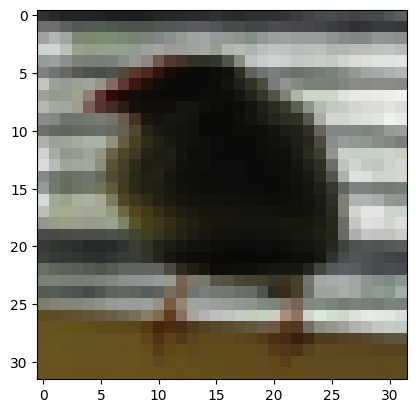

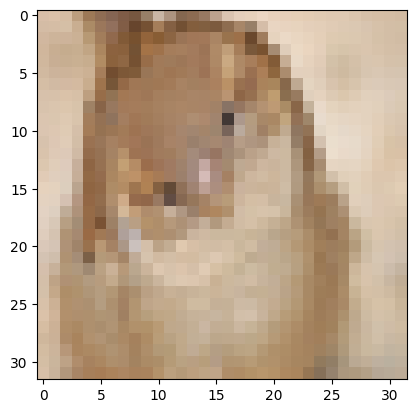

In [4]:
# Visualize some data samples of class '2' (bird)
import matplotlib.pyplot as plt
imgplot = plt.imshow(data[50])
plt.show()
imgplot = plt.imshow(data[5500])
plt.show()

# Build the Generator

In [5]:
# Define the structure of Generator
def define_generator(latent_dim):
  # latent_dim: dimension of the random input vector
  model = Sequential()  # Initialize a sequential model for Generator

  # Foundation for 4x4 image
  n_nodes = 4*4*256    # Expected vector size for converting to a feature map
  model.add(Dense(input_dim=latent_dim, units=n_nodes))  # FC layer to convert latent vector to a vector of size n_nodes
  model.add(Reshape((4, 4, 256)))
  model.add(LeakyReLU(alpha=0.2))

  # Upsample from 4x4x256 to 8x8x128
  model.add(Conv2DTranspose(128, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Upsample from 8x8x128 to 16x16x64
  model.add(Conv2DTranspose(64, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Upsample from 16x16x64 to 32x32x32
  model.add(Conv2DTranspose(32, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Convert from 32x32x32 to 32x32x3 conforming to Discriminator's input
  model.add(Conv2D(3, (5,5), activation='tanh', padding='same'))

  return model          # Return the Generator

# Show a sample of Generator structure
generator = define_generator(256)
generator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 4096)              1052672   
                                                                 
 reshape (Reshape)           (None, 4, 4, 256)         0         
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 4, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 128)         295040    
 anspose)                                                        
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 16, 16, 64)        73792     
 Transpose)                                             

# Build the Discriminator

In [6]:
# Define the structure of Discriminator
def define_discriminator(in_shape=(32,32,3)):
  model = Sequential()  # Initialize a sequential model for Discriminator

  # Block 1 conv
  model.add(Conv2D(16, (3,3), padding='same', input_shape=in_shape))
  model.add(LeakyReLU(alpha=0.2))

  # Block 2 conv
  model.add(Conv2D(32, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Block 3 conv
  model.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Block 4 conv
  model.add(Conv2D(128, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Block 5 conv
  model.add(Conv2D(256, (3,3), strides=(2, 2), padding='same'))
  model.add(LeakyReLU(alpha=0.2))

  # Classifier
  model.add(Flatten())
  model.add(Dropout(0.5))
  model.add(Dense(1, activation='sigmoid'))

  return model          # Return the Discriminator

# Show a sample of Discriminator structure
sample_discriminator = define_discriminator()
sample_discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 32, 32, 16)        448       
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 32, 32, 16)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 32)        4640      
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 16, 16, 32)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 64)          18496     
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 8, 8, 64)          0         
                                                                 
 conv2d_4 (Conv2D)           (None, 4, 4, 128)        

# Build GAN with the Generator and the Discriminator

In [7]:
# Define GAN network consisting of a Generator and a Discriminator
def define_gan(g_model, d_model):
    # g_model: Generator component; d_model: Discriminator component
    model = Sequential()  # Initialize a sequential model
    model.add(g_model)    # Add the Generator component
    model.add(d_model)    # Add the Discriminator component
    return model          # Return the GAN

# Prepare real data samples from the CIFAR 10 dataset

In [8]:
# Load and normalize CIFAR 10 images of the selected class
def load_real_samples():
    # Load dataset
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    label = 2                                      # Class '2' is bird
    train_indices = np.where(y_train == label)[0]  # Get indices of the label
    train_set = X_train[train_indices]
    test_indices = np.where(y_test == label)[0]    # Get indices of the label
    test_set = X_test[test_indices]
    X = np.vstack((train_set, test_set))

    # Convert pixel values from unsigned int to float32 for normalization calculation
    X = X.astype('float32')

    # Because the generator is using tanh activation, we need to normalize real images from range [0,255] into range [-1,1]
    X = (X - 127.5) / 127.5

    return X  # Return the set of normalized images

# Select real samples from the real dataset for training purpose
def generate_real_samples(dataset, n_samples):
    # Generate random n_samples sample indices from the dataset
    ix = np.random.randint(0, dataset.shape[0], size = n_samples)

    # Get the images from the list of indices
    X = dataset[ix]

    # Generate labels for the real samples (label=1)
    y = np.ones((n_samples, 1))

    return X, y  # Return the real images and labels

# Generate fake data samples by passing a random vector through the Generator

In [9]:
# Generate random latent vectors as input for Generator
def generate_latent_points(latent_dim, n_samples):
    # Generate points in the latent space
    x_input = np.random.randn(latent_dim * n_samples)

    # Reshape to a batch of inputs for the Generator
    x_input = x_input.reshape(n_samples, latent_dim)

    return x_input

# Use Generator to generate n_samples fake samples
def generate_fake_samples(g_model, latent_dim, n_samples):
    # Generate random latent vectors as input for Generator
    x_input = generate_latent_points(latent_dim, n_samples)

    # Generate fake data samples by passing the random latent vectors through the Generator
    X = g_model.predict(x_input)

    # Generate labels for the fake samples (label=0)
    y = np.zeros((n_samples, 1))

    return X, y  # Return the fake images and labels

# Training process with the Generator and the Discriminator

In [10]:
# Train the Generator and the Discriminator
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs, n_batch):
    bat_per_epo = int(dataset.shape[0] / n_batch)  # Number of iterations per epoch
    half_batch = int(n_batch / 2)                  # A batch to the Discriminator contains real samples (half-batch) and fake samples (half-batch)

    g_loss_values = []                             # Array containing Generator loss over iterations
    d_loss_real_values = []                        # Array containing Discriminator loss on real samples over iterations
    d_loss_fake_values = []                        # Array containing Discriminator loss on fake samples over iterations

    # Number of epochs
    for i in range(n_epochs):
        # Number of iterations
        for j in range(bat_per_epo):

            # Randomly get half_batch real data samples from the real dataset
            X_real, y_real = generate_real_samples(dataset, half_batch)

            # Generate half_batch fake data samples
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)

            # Update discriminator model weights
            d_loss1, _ = d_model.train_on_batch(X_real, y_real)
            d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)

            # Generate random latent vectors as input for Generator
            X_gan = generate_latent_points(latent_dim, n_batch)

            # Generate inverted labels for the fake samples to train the Generator
            y_gan = np.ones((n_batch, 1))

            # Train the Generator
            g_loss = gan_model.train_on_batch(X_gan, y_gan)

            # Training log after every iteration
            print('Epoch %d, Iteration %d/%d, D_loss_real = %.3f, D_loss_fake = %.3f, G_loss = %.3f' % (i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))

            # Add loss values to historical arrays
            g_loss_values.append(g_loss)
            d_loss_real_values.append(d_loss1)
            d_loss_fake_values.append(d_loss2)

        # Plot the generated images every certain number of epochs
        if (i+1) % 10 == 0:
            X_fake, _ = generate_fake_samples(g_model, latent_dim, 49)  # Generate 49 fake data samples using the Generator
            save_plot(X_fake, i, n=7)                                   # Plot a grid of 7x7 fake samples and save to file at epoch i

    return d_loss_real_values, d_loss_fake_values, g_loss_values        # Return the loss arrays of Generator and Discriminator

# Plot the Generator's outputs

In [11]:
# Create and save a plot of generated images
def save_plot(samples, epoch, n):
    # Define a plot of (n rows, n columns)
    for i in range(n * n):
        # (i + 1) is the index position on a grid with nrows rows and ncols columns. Index starts at 1 in the upper left corner and increases to the right.
        plt.subplot(n, n, i+1)
        plt.axis('off')                                 # Disable axis
        # Plot the sample i, convert pixel values from range [-1,1] into range [0,255]
        plt.imshow(((samples[i] * 127.5) + 127.5).astype(np.uint8))
    filename = 'Plot_epoch_%03d.png' % (epoch+1)
    plt.savefig(filename)                               # Save plot to file
    plt.close()                                         # Close the plot

# Main code

In [12]:
# Size of the latent space
latent_dim = 256
epochs = 500
batch_size = 128

# Initialize an optimizer
opt = Adam(learning_rate=0.0001, beta_1 = 0.5)

# Create the Generator
g_model = define_generator(latent_dim)

# Create the Discriminator
d_model = define_discriminator()
d_model.trainable = True
d_model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

# Create the GAN
d_model.trainable = False
gan_model = define_gan(g_model, d_model)
gan_model.compile(loss='binary_crossentropy', optimizer=opt)

# Load real image data from the CIFAR 10 dataset
dataset = load_real_samples()

# Train the GAN
d_losses_real, d_losses_fake, g_losses = train(g_model, d_model, gan_model, dataset, latent_dim, epochs, batch_size)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
Epoch 446, Iteration 34/46, D_loss_real = 0.601, D_loss_fake = 0.673, G_loss = 0.802
2/2 [==============================] - 0s 3ms/step
Epoch 446, Iteration 35/46, D_loss_real = 0.643, D_loss_fake = 0.616, G_loss = 0.817
2/2 [==============================] - 0s 3ms/step
Epoch 446, Iteration 36/46, D_loss_real = 0.630, D_loss_fake = 0.682, G_loss = 0.754
2/2 [==============================] - 0s 3ms/step
Epoch 446, Iteration 37/46, D_loss_real = 0.597, D_loss_fake = 0.673, G_loss = 0.776
2/2 [==============================] - 0s 3ms/step
Epoch 446, Iteration 38/46, D_loss_real = 0.589, D_loss_fake = 0.642, G_loss = 0.787
2/2 [==============================] - 0s 3ms/step
Epoch 446, Iteration 39/46, D_loss_real = 0.666, D_loss_fake = 0.658, G_loss = 0.821
2/2 [==============================] - 0s 3ms/step
Epoch 446, Iteration 40/46, D_loss_real = 0.664, D_loss_fake = 0.664, G_loss = 0.815
2/2 [==============================] - 0s 

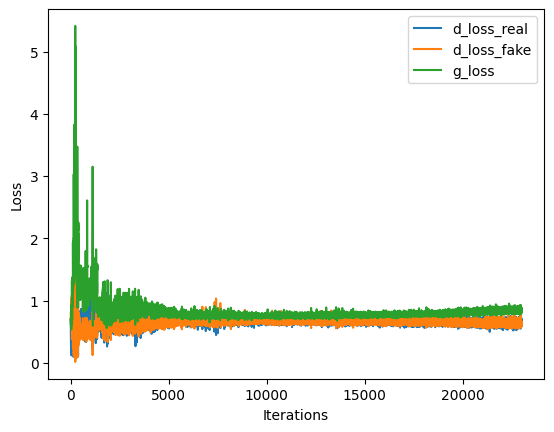

In [13]:
### Plot the training loss of the Generator and the Discriminator over iterations

# Initialize values of x-axis (iterations)
gx = np.linspace(0, len(g_losses), len(g_losses))
dx_real = np.linspace(0, len(d_losses_real), len(d_losses_real))
dx_fake = np.linspace(0, len(d_losses_fake), len(d_losses_fake))

# Plot the training loss of G and D
plt.plot(dx_real, d_losses_real)
plt.plot(dx_fake, d_losses_fake)
plt.plot(gx, g_losses)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.legend(['d_loss_real', 'd_loss_fake', 'g_loss'], loc='upper right')
plt.show()

# Save and load the models

In [14]:
# Save the Generator, Discriminator and GAN model
g_model.save('g_model.sav')
d_model.save('d_model.sav')
gan_model.save('gan_model.sav')

In [15]:
# Load the Generator from saved model
g_model = keras.models.load_model("g_model.sav")

# Generate 49 fake images by passing 256-dimensional random vectors through the Generator
X_fake, _ = generate_fake_samples(g_model, 256, 49)

2/2 [==============================] - 0s 4ms/step


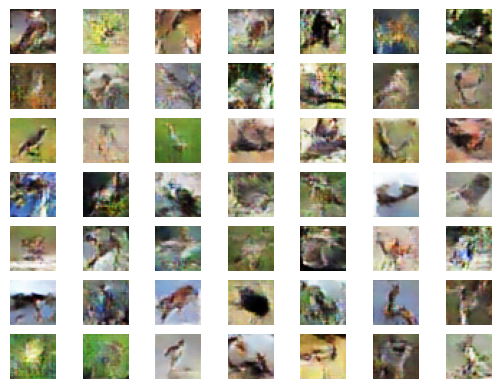

In [16]:
# Visualize all generated images
for i in range(49):
  plt.subplot(7, 7, 1 + i)
  plt.axis('off')
  plt.imshow(((X_fake[i] * 127.5) + 127.5).astype(np.uint8))  # Convert pixel values from range [-1,1] into range [0,255]
plt.show()

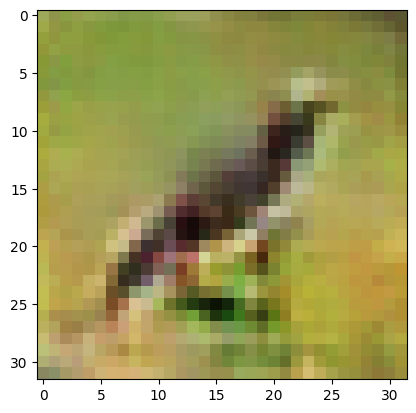

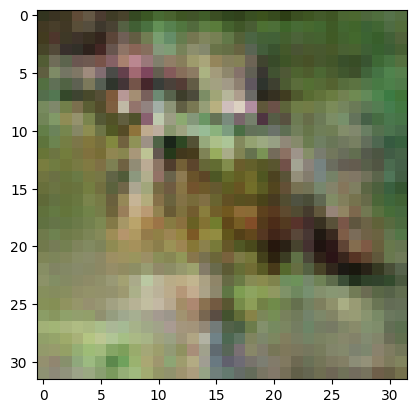

In [27]:
# Visualize some individual generated images
imgplot = plt.imshow(((X_fake[14] * 127.5) + 127.5).astype(np.uint8))
plt.show()
imgplot = plt.imshow(((X_fake[25] * 127.5) + 127.5).astype(np.uint8))
plt.show()

In [18]:
# Compress output folders for downloading
!zip -r /content/d_model.zip /content/d_model.sav
!zip -r /content/g_model.zip /content/g_model.sav
!zip -r /content/gan_model.zip /content/gan_model.sav

  adding: content/d_model.sav/ (stored 0%)
  adding: content/d_model.sav/keras_metadata.pb (deflated 92%)
  adding: content/d_model.sav/variables/ (stored 0%)
  adding: content/d_model.sav/variables/variables.index (deflated 67%)
  adding: content/d_model.sav/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: content/d_model.sav/fingerprint.pb (stored 0%)
  adding: content/d_model.sav/saved_model.pb (deflated 88%)
  adding: content/d_model.sav/assets/ (stored 0%)
  adding: content/g_model.sav/ (stored 0%)
  adding: content/g_model.sav/keras_metadata.pb (deflated 92%)
  adding: content/g_model.sav/variables/ (stored 0%)
  adding: content/g_model.sav/variables/variables.index (deflated 52%)
  adding: content/g_model.sav/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: content/g_model.sav/fingerprint.pb (stored 0%)
  adding: content/g_model.sav/saved_model.pb (deflated 89%)
  adding: content/g_model.sav/assets/ (stored 0%)
  adding: content/gan_model.sav/ (stor

In [19]:
# Download the Generator, Discriminator and GAN model
files.download("/content/g_model.zip")
files.download("/content/d_model.zip")
files.download("/content/gan_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>